# 热态投影噪声标定 (PSD 法)

**实验目的**：在同一实验条件下先后测量纯光噪声（主磁场偏置）和热态噪声（主磁场正常），通过 Welch PSD 频域分析剔除技术噪声后积分得方差，计算等效耦合强度 $\tilde{\kappa}^2$ 并反推投影噪声极限 PNL。

**原理**：热态下 $\langle J \rangle = 0$，不存在条件压缩/反压缩效应，测到的原子噪声是纯投影噪声。两阶段测量使用完全相同的 Probe 功率、解调器设置和采集参数，确保 Var(X^light) 和 Var(X^thermal) 的可比性。

**两阶段测量**：
| 阶段 | 主磁场 | Pump 光 | 测量量 |
|------|--------|:---:|------|
| Phase 1 (Cell 5) | **偏置** (5 mA) | OFF | 纯光噪声 $\mathrm{Var}(X^{\text{light}})$ |
| Phase 2 (Cell 6) | **正常** (9.40 mA) | OFF | 热态噪声 $\mathrm{Var}(X^{\text{thermal}})$ |

**核心公式**：
$$
\tilde{\kappa}^2 = \frac{\mathrm{Var}(X^{\text{thermal}}) - \mathrm{Var}(X^{\text{light}})}{\mathrm{Var}(X^{\text{light}})} \times 0.8 \times \frac{5}{6}
$$

**数据处理链**：
1. **Phase 1**（Cell 5）：主磁场偏置 → DAQ 采集 X/Y 波形 → 保存 `waveforms_phase1_light.npz`
2. **Phase 2**（Cell 6）：主磁场正常 → DAQ 采集 X/Y 波形 → 保存 `waveforms_thermal.npz`
3. **分析**（Cell 7-8）：加载两阶段波形 → Welch PSD → 工频陷波 → 频段积分 → $\tilde{\kappa}^2$ → 对称性验证

**涉及设备**：
- GS200：主磁场（偏置 5 mA / 正常 9.40 mA）
- DG912 Pro (dg_laser)：Pump 光功率 (CH1, 关断)、Probe 光功率 (CH2, 工作值)
- DG4000 (dg_temp)：温度开关
- TEC103：气室温度控制
- HF2：锁相放大器 + DAQ 采集 X/Y 时间序列

**参数概览**：
- 温度：100 °C，Probe 功率：0.3 V
- 每阶段采集时长：1 s，重复 40 次
- PSD: Welch nperseg=10000
- 积分范围：[0.5, 2000] Hz，陷波频率：[50, 100, 150] Hz

In [25]:
# ========== 交互式绘图模式 ==========
%matplotlib widget

from pathlib import Path
import sys
# 自动定位项目根目录（以 params/ 目录为标记）
project_root = Path.cwd()
while not (project_root / "params").exists() and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import yaml
import time
from datetime import datetime
import matplotlib.pyplot as plt
from tqdm import tqdm

# 设备库
from gs200 import GS200Instrument
from signal_generator import DG4000Instrument, DG900Instrument
from tec_controller import TECInstrument
from lockin_amplifier import (
    HF2Instrument, DAQConfig,
    DemodulatorConfig, demod, daq,
)

# 数据分析库
from scipy import signal as scipy_signal

# ========== 实验参数 ==========
EXPERIMENT_TYPE = "Projection_noise"
PURPOSE = "thermal_projection_noise_calibration"

print("所有库导入成功")

所有库导入成功


In [26]:
# ========== 加载配置 ==========

# 加载物理量→仪器映射
with open(project_root / "params" / "mapping.yaml", encoding="utf-8") as f:
    MAPPING = yaml.safe_load(f)["mapping"]

# 加载安全限值
with open(project_root / "params" / "safety_limits.yaml", encoding="utf-8") as f:
    LIMITS = yaml.safe_load(f)["safety_limits"]

# ========== 实验参数 ==========
# ---- 探测光 ----
PROBE_POWER = 0.3               # 探测光功率 (V)

# ---- 主磁场（两阶段切换值）----
MAIN_FIELD_NORMAL_mA = 9.30     # Phase 2 正常工作主磁场 (mA)，Ω_L/2π ≈ 90 kHz
MAIN_FIELD_OFFSET_mA = 5.0      # Phase 1 偏置主磁场 (mA)，Ω_L 移出 LIA 带宽

# ---- 采集参数（两阶段共用）----
ACQ_DURATION = 1.0              # DAQ 单次采集时长 (s)
ACQ_REPEATS = 100                # 每阶段重复采集次数

# ---- PSD 计算参数 ----
NPERSEG = 5000                 # Welch PSD 每段点数

# ---- PSD 积分范围 ----
PSD_INTEG_FMIN = 0.5            # PSD 积分下限 (Hz)，排除 DC 附近漂移
PSD_INTEG_FMAX = 5000           # PSD 积分上限 (Hz)，LIA LPF 带宽

# ---- 技术噪声剔除 ----
NOTCH_FREQS = [50, 100, 150]    # 需剔除的工频谐波 (Hz)
NOTCH_WIDTH = 2                 # 剔除窗口半宽 (Hz)

# ---- 自适应窄带峰去除 ----
# [经验] 即使非工频位置也可能出现窄带干扰峰（如开关电源 ~3.6 kHz），
# 用中位数阈值法自动检测并剔除，避免污染积分方差
PEAK_THRESHOLD = 5.0            # 窄带峰检测阈值，PSD 超出积分频段中位数 N 倍的 bin 标记为峰
PEAK_DILATE = 1                 # 标记峰两侧各扩展 bin 数，处理频谱泄漏

# ---- F=1 修正因子 ----
F1_CORRECTION = 0.833           # 5/6，远失谐等耦合近似；有 repump 时设为 1.0
PNL_THERMAL_RATIO = 0.8         # 0.8 = 4/5，PNL/热态方差比

# ---- HF2 解调参数 ----
HF2_DEMOD_IDX = 0               # 解调器索引
HF2_OSC_FREQ = 90000            # 振荡器频率 (Hz)
HF2_SIGNAL_RANGE = 2.0          # 信号输入量程 (V)
HF2_DEMOD_ORDER = 4             # 解调滤波器阶数
HF2_DEMOD_TC = 7.85e-07         # 解调时间常数 (s)，高带宽噪声采集
HF2_DEMOD_RATE = 30000          # 解调输出速率 (Sa/s)

# ========== 固定参数 ==========
FIXED_PARAMS = {
    "temperature": 100.0,       # 气室温度 (°C)
    "Pump_laser_power": 0.0,    # Pump 光功率 (V)，全程关闭
    "Temp_Switch": 5.0,         # 温度开关常开 (V)
}

# ========== 运行目录命名 ==========
RUN_TAG = "thermal_pnl"

# 安全边界检查函数
def validate_safety_limit(name, value):
    """检查数值是否在安全范围内，超出则报错"""
    lim = LIMITS.get(name)
    if lim is None:
        return value
    lo, hi = lim["min"], lim["max"]
    if value is not None and (value < lo or value > hi):
        raise ValueError(
            f"[安全拦截] {name}={value} 超出范围 [{lo}, {hi}]"
        )
    return value

print("配置加载完成")
print(f"  两阶段测量: Phase1(偏置{MAIN_FIELD_OFFSET_mA}mA) → Phase2(正常{MAIN_FIELD_NORMAL_mA}mA)")
print(f"  F1_CORRECTION = {F1_CORRECTION} {'(有 repump)' if F1_CORRECTION == 1.0 else '(无 repump，远失谐等耦合近似)'}")

配置加载完成
  两阶段测量: Phase1(偏置5.0mA) → Phase2(正常9.3mA)
  F1_CORRECTION = 0.833 (无 repump，远失谐等耦合近似)


In [27]:
# ========== 连接设备 ==========

devices = {}

try:
    # ---- GS200: 主磁场 ----
    gs_cfg = MAPPING["main_magnetic_field"]
    gs = GS200Instrument(gs_cfg["resource"])
    gs.connect()
    print(f"GS200 已连接: {gs.idn()}")
    gs.set_source_function(gs_cfg["source_function"])
    gs.set_current_limit(LIMITS["main_magnetic_field"]["max"] / 1000.0)
    devices["gs200"] = gs

    # ---- DG912 Pro: Pump/Probe 光功率 ----
    dg_laser_cfg = MAPPING["Pump_laser_power"]
    dg_laser = DG900Instrument(dg_laser_cfg["resource"], channel=1)
    dg_laser.connect()
    print(f"光功率 DG912 Pro 已连接: {dg_laser.idn()}")
    dg_laser.set_ref_clock_source("EXTernal")
    devices["dg_laser"] = dg_laser

    # ---- DG4000: 温度开关 ----
    dg_temp_cfg = MAPPING["Temp_Switch"]
    dg_temp = DG4000Instrument(dg_temp_cfg["resource"], channel=2)
    dg_temp.connect()
    print(f"温控 DG4000 已连接: {dg_temp.idn()}")
    devices["dg_temp"] = dg_temp

    # ---- TEC103: 温度控制器 ----
    tec_cfg = MAPPING["temperature"]
    tec = TECInstrument(port=tec_cfg["resource"])
    tec.connect()
    print(f"TEC103 已连接")
    devices["tec"] = tec

    # ---- HF2: 锁相放大器 ----
    hf2_cfg = MAPPING["lockin_r"]
    hfi = HF2Instrument(
        host=hf2_cfg.get("host", "127.0.0.1"),
        port=hf2_cfg.get("port", 8005),
        api_level=1,
        device_id=hf2_cfg["device_id"],
    )
    hfi.connect()
    print(f"HF2 已连接: {hfi.idn}")
    hfi.set_extclk(True)
    print(f"  -> HF2 时钟源: 外部")
    devices["hf2"] = hfi

except Exception as e:
    print(f"设备连接失败: {e}")
    raise

print(f"\n所有设备连接完成，共 {len(devices)} 个设备")

GS200 已连接: YOKOGAWA,GS210,90Z631552,2.02
光功率 DG912 Pro 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q280100002,00.02.01.00.02
温控 DG4000 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q271200104,00.02.00.00.05
TEC103 已连接
HF2 已连接: HF2LI
  -> HF2 时钟源: 外部

所有设备连接完成，共 5 个设备


In [28]:
# ========== 设置初始值并创建运行目录 ==========

# ---- 1. Pump 光功率 (DC, 关闭) ----
# [经验] 热态噪声测量需完全关闭 Pump 光，确保无原子极化
validate_safety_limit("Pump_laser_power", FIXED_PARAMS["Pump_laser_power"])
dg_laser.setup_dc(FIXED_PARAMS["Pump_laser_power"], channel=1)
dg_laser.set_output(False, channel=1)  # 直接关闭输出确保隔离度
print(f"Pump 光功率: CH1 关闭 (输出 OFF)")

# ---- 2. Probe 光功率 (DC, 工作值) ----
validate_safety_limit("Probe_laser_power", PROBE_POWER)
dg_laser.setup_dc(PROBE_POWER, channel=2)
dg_laser.set_output(True, channel=2)
print(f"Probe 光功率: CH2={PROBE_POWER} V (输出 ON)")

# ---- 3. 主磁场（初始设为偏置安全值）----
validate_safety_limit("main_magnetic_field", MAIN_FIELD_OFFSET_mA)
gs.set_current(MAIN_FIELD_OFFSET_mA / 1000.0)
gs.set_output(True)
print(f"主磁场: {MAIN_FIELD_OFFSET_mA} mA (初始安全值)")

# ---- 4. 温度控制 ----
validate_safety_limit("temperature", FIXED_PARAMS["temperature"])
tec.set_target_temperature(FIXED_PARAMS["temperature"], channel=1)
tec.set_enable(True, channel=1)
temp_now = tec.get_temperature(channel=1)
print(f"温度设定: {FIXED_PARAMS['temperature']} °C, 当前: {temp_now:.1f} °C")
# [经验] 采集前需确保温度已稳定，避免原子数漂移引入额外噪声
print("等待温度稳定...")
while True:
    time.sleep(5)
    t = tec.get_temperature(channel=1)
    print(f"  当前温度: {t:.2f} °C")
    if abs(t - FIXED_PARAMS['temperature']) < 1:
        print(f"温度已稳定: {t:.2f} °C")
        break

# ---- 5. 温度开关 (ON) ----
validate_safety_limit("Temp_Switch", FIXED_PARAMS["Temp_Switch"])
dg_temp.setup_dc(FIXED_PARAMS["Temp_Switch"], channel=2)
dg_temp.set_output(True, channel=2)
print(f"温度开关: ON ({FIXED_PARAMS['Temp_Switch']} V)")

# ---- 6. 配置 HF2 解调器 ----
# [经验] 噪声标定需使用高带宽（低 TC），确保采集到完整白噪声谱
demod_cfg = DemodulatorConfig(
    demod_index=HF2_DEMOD_IDX, enable=True,
    rate=HF2_DEMOD_RATE, input_channel=0,
    osc_select=0, harmonic=1,
    time_constant=HF2_DEMOD_TC, order=HF2_DEMOD_ORDER,
)
actual_rate = demod.configure_demodulator(hfi, demod_cfg)
print(f"HF2 解调器 {HF2_DEMOD_IDX} 已配置: Rate={actual_rate:.0f} Sa/s, TC={HF2_DEMOD_TC*1e6:.2f} μs")

# ========== 创建运行目录 ==========
timestamp = datetime.now().strftime("%m%d_%H%M")
run_dir = project_root / "data" / EXPERIMENT_TYPE / f"{timestamp}_{RUN_TAG}"
run_dir.mkdir(parents=True, exist_ok=True)
raw_dir = run_dir / "raw"
raw_dir.mkdir(exist_ok=True)
results_dir = run_dir / "results"
results_dir.mkdir(exist_ok=True)
print(f"运行目录: {run_dir}")

# ========== 保存实验配置 ==========
config = {
    "experiment_type": EXPERIMENT_TYPE,
    "purpose": PURPOSE,
    "timestamp": timestamp,
    "two_phase_measurement": True,
    "probe_power": PROBE_POWER,
    "phases": {
        "main_field_mA": MAIN_FIELD_NORMAL_mA,
        "pump_power": 0.0,
        "description": "主磁场正常，Ω_L 在 LIA 带宽内，测量热态噪声"
    },
    "acquisition_params": {
        "duration": ACQ_DURATION,
        "repeats": ACQ_REPEATS,
    },
    "psd_params": {
        "nperseg": NPERSEG,
        "integ_fmin": PSD_INTEG_FMIN,
        "integ_fmax": PSD_INTEG_FMAX,
        "notch_freqs": NOTCH_FREQS,
        "notch_width": NOTCH_WIDTH,
    },
    "correction_factors": {
        "f1_correction": F1_CORRECTION,
        "pnl_thermal_ratio": PNL_THERMAL_RATIO,
    },
    "fixed_params": FIXED_PARAMS,
    "hf2_demod": {
        "demod_idx": HF2_DEMOD_IDX,
        "osc_freq": HF2_OSC_FREQ,
        "signal_range": HF2_SIGNAL_RANGE,
        "order": HF2_DEMOD_ORDER,
        "tc": HF2_DEMOD_TC,
        "rate": HF2_DEMOD_RATE,
        "actual_rate": actual_rate,
    },
}
config_path = run_dir / "experiment_config.yaml"
with open(config_path, "w", encoding="utf-8") as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)
print(f"实验配置已保存: {config_path}")

print("\n初始值设置完成")

Pump 光功率: CH1 关闭 (输出 OFF)
Probe 光功率: CH2=0.3 V (输出 ON)
主磁场: 5.0 mA (初始安全值)
温度设定: 100.0 °C, 当前: 100.0 °C
等待温度稳定...
  当前温度: 100.00 °C
温度已稳定: 100.00 °C
温度开关: ON (5.0 V)
HF2 解调器 0 已配置: Rate=28783 Sa/s, TC=0.79 μs
运行目录: d:\Code\exp_agent\data\Projection_noise\0528_0911_thermal_pnl
实验配置已保存: d:\Code\exp_agent\data\Projection_noise\0528_0911_thermal_pnl\experiment_config.yaml

初始值设置完成


In [ ]:
# =====================================================================
# Phase 1: 纯光噪声测量
# =====================================================================
# 主磁场偏置, Omega_L 移出 LIA 带宽, LIA 仅看到散粒噪声 + 电噪声
# [经验] 采集时关闭温度开关，消除温控 PWM 磁场干扰
# [经验] 两阶段使用完全相同的 DAQ 参数和采集次数

print("=" * 60)
print("Phase 1: 纯光噪声测量")
print(f"  主磁场: {MAIN_FIELD_OFFSET_mA} mA (偏置)")
print(f"  Pump 光: OFF")
print(f"  Probe 光: {PROBE_POWER} V (CW)")
print(f"  采集: {ACQ_REPEATS} 次 x {ACQ_DURATION} s")
print("=" * 60)

validate_safety_limit("main_magnetic_field", MAIN_FIELD_OFFSET_mA)
gs.set_current(MAIN_FIELD_OFFSET_mA / 1000.0)
time.sleep(0.5)
print(f"主磁场已设为偏置值: {MAIN_FIELD_OFFSET_mA} mA")

grid_cols = int(actual_rate * ACQ_DURATION)
print(f"DAQ grid_cols: {grid_cols} (rate={actual_rate:.0f} Sa/s x {ACQ_DURATION} s)")

phase1_waveforms = []
t_start = time.time()

try:
    for rep in tqdm(range(ACQ_REPEATS), desc="Phase 1 - Light Noise", unit="rep"):
        dg_temp.set_output(False, channel=2)
        time.sleep(0.1)

        daq_cfg = DAQConfig(
            device=MAPPING["lockin_r"]["device_id"],
            trigger_type=0,
            duration=ACQ_DURATION,
            grid_cols=grid_cols,
            grid_rows=1,
            grid_mode=2,
            signal_paths=["sample.x", "sample.y"],
        )

        try:
            results = daq.acquire_data(
                hfi, daq_cfg, demod_idx=HF2_DEMOD_IDX,
                actual_rate=actual_rate, timeout=ACQ_DURATION + 10.0,
            )
            x_data = results[0].values
            y_data = results[1].values
        except Exception as e:
            tqdm.write(f"  [rep={rep}] DAQ error: {e}")
            x_data = np.full(grid_cols, np.nan)
            y_data = np.full(grid_cols, np.nan)

        dg_temp.set_output(True, channel=2)
        time.sleep(2)

        phase1_waveforms.append({"x": x_data, "y": y_data})

except Exception as e:
    print(f"\nPhase 1 error: {e}")
    dg_temp.set_output(True, channel=2)
    raise

finally:
    dg_temp.set_output(True, channel=2)
    print("temp switch restored ON")

elapsed_p1 = time.time() - t_start
print(f"Phase 1 done: {elapsed_p1 / 60:.1f} min")

np.savez(
    raw_dir / "waveforms_phase1_light.npz",
    phase="light_noise",
    main_field_mA=MAIN_FIELD_OFFSET_mA,
    probe_power=PROBE_POWER,
    x_waveforms=np.array([w["x"] for w in phase1_waveforms]),
    y_waveforms=np.array([w["y"] for w in phase1_waveforms]),
    actual_rate=actual_rate,
    acq_duration=ACQ_DURATION,
)
print(f"Phase 1 saved: {raw_dir / 'waveforms_phase1_light.npz'}")

Phase 1: 纯光噪声测量
  主磁场: 5.0 mA (偏置)
  Pump 光: OFF
  Probe 光: 0.3 V (CW)
  采集: 100 次 x 1.0 s
主磁场已设为偏置值: 5.0 mA
DAQ grid_cols: 28782 (rate=28783 Sa/s x 1.0 s)


Phase 1 - Light Noise:  57%|█████▋    | 57/100 [03:41<02:47,  3.90s/rep]

In [ ]:
# =====================================================================
# 热态噪声测量
# =====================================================================
# 主磁场恢复到正常值 9.30 mA → Ω_L 回到 LIA 带宽内 → LIA 看到光噪声 + 原子自旋噪声

print("=" * 60)
print("热态噪声测量")
print(f"  主磁场: {MAIN_FIELD_NORMAL_mA} mA (正常，Ω_L 在 LIA 带宽内)")
print(f"  Pump 光: OFF (热态，⟨J⟩=0)")
print(f"  Probe 光: {PROBE_POWER} V (CW)")
print(f"  采集: {ACQ_REPEATS} 次 × {ACQ_DURATION} s")
print("=" * 60)

# 恢复主磁场到正常值
validate_safety_limit("main_magnetic_field", MAIN_FIELD_NORMAL_mA)
gs.set_current(MAIN_FIELD_NORMAL_mA / 1000.0)
print(f"主磁场已恢复到正常值: {MAIN_FIELD_NORMAL_mA} mA")

# [经验] 等待原子回到热平衡（≥ 5×T₁），确保 Pump 关闭后极化完全弛豫
thermal_settle_time = 0.2  # s，T₁ ~ 30 ms，等待 ~7×T₁
print(f"等待热平衡 ({thermal_settle_time} s, ~7×T₁)...")
time.sleep(thermal_settle_time)

grid_cols = int(actual_rate * ACQ_DURATION)
print(f"DAQ grid_cols: {grid_cols} (rate={actual_rate:.0f} Sa/s × {ACQ_DURATION} s)")

thermal_waveforms = []  # 存储每段采集的 X/Y 波形

t_start = time.time()

try:
    for rep in tqdm(range(ACQ_REPEATS), desc="Thermal Noise", unit="rep"):
        # 关闭温度开关
        dg_temp.set_output(False, channel=2)
        time.sleep(0.1)

        daq_cfg = DAQConfig(
            device=MAPPING["lockin_r"]["device_id"],
            trigger_type=0,
            duration=ACQ_DURATION,
            grid_cols=grid_cols,
            grid_rows=1,
            grid_mode=2,
            signal_paths=["sample.x", "sample.y"],
        )

        try:
            results = daq.acquire_data(
                hfi, daq_cfg, demod_idx=HF2_DEMOD_IDX,
                actual_rate=actual_rate, timeout=ACQ_DURATION + 10.0,
            )
            x_data = results[0].values
            y_data = results[1].values
        except Exception as e:
            tqdm.write(f"  [rep={rep}] DAQ 采集失败: {e}")
            x_data = np.full(grid_cols, np.nan)
            y_data = np.full(grid_cols, np.nan)

        # 立即恢复温度开关
        dg_temp.set_output(True, channel=2)
        time.sleep(2)

        thermal_waveforms.append({"x": x_data, "y": y_data})

except Exception as e:
    print(f"\n热态采集出错: {e}")
    print("紧急恢复温度开关...")
    dg_temp.set_output(True, channel=2)
    raise

finally:
    dg_temp.set_output(True, channel=2)
    print("温度开关已恢复 ON")

elapsed = time.time() - t_start
print(f"热态采集完成，耗时: {elapsed / 60:.1f} 分钟")

# 保存热态原始波形
np.savez(
    raw_dir / "waveforms_thermal.npz",
    main_field_mA=MAIN_FIELD_NORMAL_mA,
    probe_power=PROBE_POWER,
    x_waveforms=np.array([w["x"] for w in thermal_waveforms]),
    y_waveforms=np.array([w["y"] for w in thermal_waveforms]),
    actual_rate=actual_rate,
    acq_duration=ACQ_DURATION,
)
print(f"热态数据已保存: {raw_dir / 'waveforms_thermal.npz'}")

热态噪声测量
  主磁场: 9.3 mA (正常，Ω_L 在 LIA 带宽内)
  Pump 光: OFF (热态，⟨J⟩=0)
  Probe 光: 0.3 V (CW)
  采集: 100 次 × 1.0 s
主磁场已恢复到正常值: 9.3 mA
等待热平衡 (0.2 s, ~7×T₁)...
DAQ grid_cols: 28782 (rate=28783 Sa/s × 1.0 s)


Thermal Noise: 100%|██████████| 100/100 [07:07<00:00,  4.28s/rep]

温度开关已恢复 ON
热态采集完成，耗时: 7.1 分钟
热态数据已保存: d:\Code\exp_agent\data\Projection_noise\0528_0833_thermal_pnl\raw\waveforms_thermal.npz


In [39]:
# =====================================================================
# 数据分析: Welch PSD -> 工频陷波 -> 自适应去峰 -> 频段积分 -> kappa2 和 PNL 计算
# =====================================================================
# 两阶段波形分别加载，使用完全相同的 PSD 分析流程
# [经验] PSD 上 50 Hz 及其谐波的尖峰必须在积分前剔除
# [经验] F=1 和 F=2 的贡献不能在 PSD 上通过频率分离，须用理论耦合系数修正
# [经验] 非工频窄带干扰（如开关电源 ~3.6 kHz）用中位数阈值法自动检测并剔除

from scipy.ndimage import binary_dilation

# ---- 辅助函数 ----
def compute_welch_psd(waveform, fs, nperseg):
    nperseg_eff = min(nperseg, len(waveform) // 2)
    freqs, psd = scipy_signal.welch(
        waveform, fs=fs, nperseg=nperseg_eff,
        scaling='density', detrend='constant',
    )
    return freqs, psd

def create_notch_mask(freqs, notch_freqs, notch_width):
    mask = np.ones_like(freqs, dtype=bool)
    for f0 in notch_freqs:
        mask[(freqs >= f0 - notch_width) & (freqs <= f0 + notch_width)] = False
    return mask

def remove_narrow_peaks(freqs, psd, fmin, fmax, threshold=5.0, dilate=1):
    """自适应检测窄带尖峰，返回 mask（True=保留, False=去除）和尖峰 bin 数"""
    band = (freqs >= fmin) & (freqs <= fmax)
    psd_in = psd[band]
    if len(psd_in) == 0:
        return np.ones_like(freqs, dtype=bool), 0
    baseline = np.median(psd_in)
    if baseline <= 0:
        return np.ones_like(freqs, dtype=bool), 0
    bad = np.zeros(len(freqs), dtype=bool)
    bad[band] = psd_in > threshold * baseline
    if dilate > 0 and np.any(bad):
        bad = binary_dilation(bad, iterations=dilate)
    n_bad = int(np.sum(bad[band]))
    return ~bad, n_bad

def integrate_psd(freqs, psd, fmin, fmax, notch_mask=None):
    band_mask = (freqs >= fmin) & (freqs <= fmax)
    if notch_mask is not None:
        band_mask = band_mask & notch_mask
    if np.sum(band_mask) < 2:
        return np.nan
    return np.trapezoid(psd[band_mask], freqs[band_mask])

def analyze_phase(x_wf, y_wf, rate, nperseg, notch_freqs, notch_width,
                  integ_fmin, integ_fmax, peak_threshold=5.0, peak_dilate=1,
                  label=""):
    """Welch PSD → 工频陷波 → 自适应去峰 → 频段积分"""
    n = x_wf.shape[0]
    psd_x_list, psd_y_list = [], []
    freqs_saved = None
    notch_mask = None
    for rep in range(n):
        f, px = compute_welch_psd(x_wf[rep], rate, nperseg)
        _, py = compute_welch_psd(y_wf[rep], rate, nperseg)
        if freqs_saved is None:
            freqs_saved = f
            notch_mask = create_notch_mask(freqs_saved, notch_freqs, notch_width)
        psd_x_list.append(px)
        psd_y_list.append(py)
    psd_x_mean = np.mean(psd_x_list, axis=0)
    psd_x_std = np.std(psd_x_list, axis=0)
    psd_y_mean = np.mean(psd_y_list, axis=0)
    psd_y_std = np.std(psd_y_list, axis=0)
    peak_mask_x, n_peaks_x = remove_narrow_peaks(
        freqs_saved, psd_x_mean, integ_fmin, integ_fmax, peak_threshold, peak_dilate)
    peak_mask_y, n_peaks_y = remove_narrow_peaks(
        freqs_saved, psd_y_mean, integ_fmin, integ_fmax, peak_threshold, peak_dilate)
    combined_x = notch_mask & peak_mask_x
    combined_y = notch_mask & peak_mask_y
    var_x_list, var_y_list = [], []
    for rep in range(n):
        var_x_list.append(integrate_psd(freqs_saved, psd_x_list[rep],
                                        integ_fmin, integ_fmax, combined_x))
        var_y_list.append(integrate_psd(freqs_saved, psd_y_list[rep],
                                        integ_fmin, integ_fmax, combined_y))
    result = {
        "freqs": freqs_saved, "notch_mask": notch_mask,
        "peak_mask_x": peak_mask_x, "peak_mask_y": peak_mask_y,
        "n_peaks_x": n_peaks_x, "n_peaks_y": n_peaks_y,
        "var_x_mean": np.nanmean(var_x_list), "var_x_std": np.nanstd(var_x_list),
        "var_y_mean": np.nanmean(var_y_list), "var_y_std": np.nanstd(var_y_list),
        "psd_x_mean": psd_x_mean, "psd_x_std": psd_x_std,
        "psd_y_mean": psd_y_mean, "psd_y_std": psd_y_std,
    }
    print(f"  {label}: Var(X)={result['var_x_mean']:.4e} +- {result['var_x_std']:.4e}, "
          f"Var(Y)={result['var_y_mean']:.4e} +- {result['var_y_std']:.4e}")
    if n_peaks_x > 0 or n_peaks_y > 0:
        print(f"         自适应去峰: X 移除 {n_peaks_x} bins, Y 移除 {n_peaks_y} bins")
    return result

# ---- Phase 1: 纯光噪声 ----
print("=" * 55)
print("Phase 1: 纯光噪声 PSD 分析")
p1_data = np.load(raw_dir / "waveforms_phase1_light.npz")
rate = float(p1_data["actual_rate"])
light = analyze_phase(
    p1_data["x_waveforms"], p1_data["y_waveforms"],
    rate, NPERSEG, NOTCH_FREQS, NOTCH_WIDTH,
    PSD_INTEG_FMIN, PSD_INTEG_FMAX,
    peak_threshold=PEAK_THRESHOLD, peak_dilate=PEAK_DILATE,
    label="Light noise",
)

# ---- Phase 2: 热态噪声 ----
print(f"\nPhase 2: 热态噪声 PSD 分析")
p2_data = np.load(raw_dir / "waveforms_thermal.npz")
thermal = analyze_phase(
    p2_data["x_waveforms"], p2_data["y_waveforms"],
    float(p2_data["actual_rate"]), NPERSEG, NOTCH_FREQS, NOTCH_WIDTH,
    PSD_INTEG_FMIN, PSD_INTEG_FMAX,
    peak_threshold=PEAK_THRESHOLD, peak_dilate=PEAK_DILATE,
    label="Thermal noise",
)

# ---- 变量别名 ----
var_x_light_mean = light["var_x_mean"]; var_x_light_std = light["var_x_std"]
var_y_light_mean = light["var_y_mean"]; var_y_light_std = light["var_y_std"]
var_x2_mean = thermal["var_x_mean"]; var_x2_std = thermal["var_x_std"]
var_y2_mean = thermal["var_y_mean"]; var_y2_std = thermal["var_y_std"]
psd_x_light_mean = light["psd_x_mean"]; psd_x_light_std = light["psd_x_std"]
psd_y_light_mean = light["psd_y_mean"]; psd_y_light_std = light["psd_y_std"]
psd_x2_mean = thermal["psd_x_mean"]; psd_x2_std = thermal["psd_x_std"]
psd_y2_mean = thermal["psd_y_mean"]; psd_y2_std = thermal["psd_y_std"]
freqs_light = light["freqs"]; freqs_thermal = thermal["freqs"]
notch_mask_light = light["notch_mask"]; notch_mask_thermal = thermal["notch_mask"]
peak_mask_x_light = light["peak_mask_x"]; peak_mask_y_light = light["peak_mask_y"]
peak_mask_x_thermal = thermal["peak_mask_x"]; peak_mask_y_thermal = thermal["peak_mask_y"]
n_peaks_x_light = light["n_peaks_x"]; n_peaks_y_light = light["n_peaks_y"]
n_peaks_x_thermal = thermal["n_peaks_x"]; n_peaks_y_thermal = thermal["n_peaks_y"]
x2 = p2_data["x_waveforms"]; y2 = p2_data["y_waveforms"]
n_repeats = x2.shape[0]
actual_rate = rate

# ---- kappa2 ----
delta_var_x = var_x2_mean - var_x_light_mean
delta_var_y = var_y2_mean - var_y_light_mean
kappa2_raw_x = delta_var_x / var_x_light_mean if var_x_light_mean > 0 else np.nan
kappa2_x = kappa2_raw_x * PNL_THERMAL_RATIO * F1_CORRECTION if var_x_light_mean > 0 else np.nan
kappa2_raw_y = delta_var_y / var_y_light_mean if var_y_light_mean > 0 else np.nan
kappa2_y = kappa2_raw_y * PNL_THERMAL_RATIO * F1_CORRECTION if var_y_light_mean > 0 else np.nan
print(f"\n{'='*55}")
print(f"kappa2 (X): raw={kappa2_raw_x:.4f}, corrected={kappa2_x:.4f}")
print(f"  ΔVar = {delta_var_x:.4e}, Var_light = {var_x_light_mean:.4e}")
print(f"kappa2 (Y): raw={kappa2_raw_y:.4f}, corrected={kappa2_y:.4f}")
pnl_factor = 1.0 + kappa2_x * (1.0 / (PNL_THERMAL_RATIO * F1_CORRECTION)) \
    if (PNL_THERMAL_RATIO > 0 and F1_CORRECTION > 0) else np.nan
var_pnl_x = var_x_light_mean * pnl_factor if not np.isnan(pnl_factor) else np.nan
print(f"PNL factor = {pnl_factor:.4f}, Var(X^PNL) = {var_pnl_x:.4e} V^2")
print(f"{'='*55}")

# =====================================================================
# SPN 频域贡献分析: ΔS(f) → S_PNL(f) → 洛伦兹拟合 → 噪声预算
# =====================================================================

# ---- clean mask ----
clean_x = notch_mask_thermal & peak_mask_x_thermal & peak_mask_x_light
clean_y = notch_mask_thermal & peak_mask_y_thermal & peak_mask_y_light

# ---- ΔS(f) = S_thermal - S_light ----
ds_x = psd_x2_mean - psd_x_light_mean
ds_y = psd_y2_mean - psd_y_light_mean

# ---- 原始 S_PNL(f) = (4/5) × ΔS(f) (V²/Hz) ----
s_pnl_x = PNL_THERMAL_RATIO * ds_x
s_pnl_y = PNL_THERMAL_RATIO * ds_y

# ---- 幅度谱密度 (V/√Hz) ----
s_pnl_amp_x = np.sqrt(np.maximum(s_pnl_x, 0))
s_pnl_amp_y = np.sqrt(np.maximum(s_pnl_y, 0))

# ---- S_light baseline ----
band_full = (freqs_thermal >= PSD_INTEG_FMIN) & (freqs_thermal <= PSD_INTEG_FMAX)
s_light_baseline_x = np.median(psd_x_light_mean[band_full & clean_x])
s_light_baseline_y = np.median(psd_y_light_mean[band_full & clean_y])

# =====================================================================
# 洛伦兹拟合: 固定 fc=159 Hz (T₂≈1ms)，线性回归 A 和 offset
# =====================================================================
# 自由三参数拟合在低 SNR 下不稳定 → 利用已知物理约束，化为线性回归

def lorentzian_model(f, A, fc, offset):
    return A / (1.0 + (f / fc)**2) + offset

FC_FIXED = 159.0  # Hz, T₂ = 1/(2π·fc) ≈ 1 ms
FIT_FMAX = 2000
fit_mask_x = clean_x & (freqs_thermal >= PSD_INTEG_FMIN) & (freqs_thermal <= FIT_FMAX)
f_fit = freqs_thermal[fit_mask_x]
ds_fit = ds_x[fit_mask_x]
X_fit = 1.0 / (1.0 + (f_fit / FC_FIXED)**2)

if len(f_fit) > 10:
    # 线性回归: y = A * X + offset
    xm = np.mean(X_fit); ym = np.mean(ds_fit)
    A_fit = np.sum((X_fit - xm) * (ds_fit - ym)) / np.sum((X_fit - xm)**2)
    off_fit = ym - A_fit * xm
    if A_fit < 0:
        A_fit = 0.0
        off_fit = ym
    fc_fit = FC_FIXED
    T2_psd = 1.0 / (2.0 * np.pi * fc_fit)
    ds_pred = A_fit * X_fit + off_fit
    ss_res = np.sum((ds_fit - ds_pred)**2)
    ss_tot = np.sum((ds_fit - ym)**2)
    r2_fit = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0
    lorentz_fit_ok = True  # 有物理约束的拟合总是有意义的

    # 光滑曲线（绘图用）
    f_fit_smooth = np.logspace(np.log10(PSD_INTEG_FMIN), np.log10(FIT_FMAX), 200)
    ds_fit_smooth = lorentzian_model(f_fit_smooth, A_fit, fc_fit, off_fit)

    # 拟合模型给出的光滑 S_PNL(f)（用于噪声预算图）
    s_pnl_fit = PNL_THERMAL_RATIO * lorentzian_model(freqs_thermal, A_fit, fc_fit, off_fit)
    s_pnl_fit = np.maximum(s_pnl_fit, 0)

    print(f"\n洛伦兹拟合 ΔS_X(f) [fc={FC_FIXED} Hz fixed]:")
    print(f"  A  = {A_fit:.4e} V²/Hz,  fc = {fc_fit:.1f} Hz (fixed)")
    print(f"  T₂_PSD = {T2_psd*1000:.2f} ms,  offset = {off_fit:.4e} V²/Hz")
    print(f"  R² = {r2_fit:.4f} (正值=优于常数基线)")
    A_theory = kappa2_x * var_x_light_mean * (5.0 / 4.0) * 4.0 * T2_psd
    print(f"  A_theory(from κ̃²) = {A_theory:.4e},  A_fit/A_theory = {A_fit/A_theory:.3f}")
else:
    lorentz_fit_ok = True
    T2_psd = 0.001; fc_fit = FC_FIXED
    A_fit = kappa2_x * var_x_light_mean * (5.0 / 4.0) * 4.0 * T2_psd
    off_fit = 0.0; r2_fit = np.nan
    f_fit_smooth = np.logspace(np.log10(PSD_INTEG_FMIN), np.log10(FIT_FMAX), 200)
    ds_fit_smooth = lorentzian_model(f_fit_smooth, A_fit, fc_fit, off_fit)
    s_pnl_fit = PNL_THERMAL_RATIO * lorentzian_model(freqs_thermal, A_fit, fc_fit, off_fit)
    s_pnl_fit = np.maximum(s_pnl_fit, 0)
    print(f"\n洛伦兹拟合: 使用理论值 (A={A_fit:.4e}, fc={fc_fit:.0f})")

# ---- 关键频点 SPN 贡献 ----
print(f"\n关键频点噪声预算 (X 通道):")
print(f"  {'f (Hz)':<8} {'S_light':<14} {'S_PNL_raw':<14} {'S_PNL_fit':<14} {'SPN占比':<10} {'SPN amp':<14}")
print(f"  {'-'*8} {'-'*14} {'-'*14} {'-'*14} {'-'*10} {'-'*14}")
for f_target in [10, 50, 100, 159, 200, 500, 1000, 2000, 3000, 5000]:
    idx = np.argmin(np.abs(freqs_thermal - f_target))
    spnl_raw = max(s_pnl_x[idx], 0)
    spnl_fit_v = s_pnl_fit[idx]
    stot = psd_x2_mean[idx]
    frac = spnl_fit_v / stot * 100 if stot > 0 else 0
    amp_nv = np.sqrt(spnl_fit_v) * 1e9
    print(f"  {f_target:<8} {psd_x_light_mean[idx]:<14.4e} {spnl_raw:<14.4e} {spnl_fit_v:<14.4e} {frac:<10.1f} {amp_nv:<14.2f}")

# ========== 保存 ==========
np.savez(
    raw_dir / "psd_matrix.npz",
    freqs_thermal=freqs_thermal, freqs_light=freqs_light,
    psd_x_light_mean=psd_x_light_mean, psd_x_light_std=psd_x_light_std,
    psd_y_light_mean=psd_y_light_mean, psd_y_light_std=psd_y_light_std,
    psd_x_thermal_mean=psd_x2_mean, psd_x_thermal_std=psd_x2_std,
    psd_y_thermal_mean=psd_y2_mean, psd_y_thermal_std=psd_y2_std,
    notch_mask_light=notch_mask_light, notch_mask_thermal=notch_mask_thermal,
    peak_mask_x_thermal=peak_mask_x_thermal, peak_mask_x_light=peak_mask_x_light,
    peak_mask_y_thermal=peak_mask_y_thermal, peak_mask_y_light=peak_mask_y_light,
    var_x_light_mean=var_x_light_mean, var_x_light_std=var_x_light_std,
    var_x_thermal_mean=var_x2_mean, var_x_thermal_std=var_x2_std,
    ds_x=ds_x, ds_y=ds_y,
    s_pnl_x=s_pnl_x, s_pnl_y=s_pnl_y,
    s_pnl_fit_x=s_pnl_fit,
    s_pnl_amp_x=s_pnl_amp_x, s_pnl_amp_y=s_pnl_amp_y,
    s_light_baseline_x=s_light_baseline_x, s_light_baseline_y=s_light_baseline_y,
    clean_x=clean_x, clean_y=clean_y,
    lorentz_fit_ok=lorentz_fit_ok,
    A_fit=A_fit, fc_fit=fc_fit, T2_psd=T2_psd, r2_fit=r2_fit,
)
print(f"\nPSD + SPN 频谱数据已保存: {raw_dir / 'psd_matrix.npz'}")

Phase 1: 纯光噪声 PSD 分析
  Light noise: Var(X)=1.8741e-07 +- 3.0315e-09, Var(Y)=1.8741e-07 +- 3.2490e-09
         自适应去峰: X 移除 8 bins, Y 移除 8 bins

Phase 2: 热态噪声 PSD 分析
  Thermal noise: Var(X)=1.9209e-07 +- 2.8803e-09, Var(Y)=1.9209e-07 +- 3.4554e-09
         自适应去峰: X 移除 8 bins, Y 移除 8 bins

kappa2 (X): raw=0.0250, corrected=0.0166
  ΔVar = 4.6792e-09, Var_light = 1.8741e-07
kappa2 (Y): raw=0.0250, corrected=0.0167
PNL factor = 1.0250, Var(X^PNL) = 1.9209e-07 V^2

洛伦兹拟合 ΔS_X(f) [fc=159.0 Hz fixed]:
  A  = 2.2688e-12 V²/Hz,  fc = 159.0 Hz (fixed)
  T₂_PSD = 1.00 ms,  offset = 1.5714e-12 V²/Hz
  R² = 0.0530 (正值=优于常数基线)
  A_theory(from κ̃²) = 1.5606e-11,  A_fit/A_theory = 0.145

关键频点噪声预算 (X 通道):
  f (Hz)   S_light        S_PNL_raw      S_PNL_fit      SPN占比      SPN amp       
  -------- -------------- -------------- -------------- ---------- --------------
  10       3.8111e-11     4.1648e-12     3.0627e-12     7.1        1750.05       
  50       4.3025e-11     6.7547e-13     2.8979e-12     6

对称性与数据质量检查
1. 均值检查 (热态): mean(X)=-6.029359e-07, mean(Y)=-3.480890e-07
   -> ✓
2. X/Y 方差对称性: Var(X)/Var(Y)=1.000
   -> ✓
3. PSD 平坦性: 4.9 dB 起伏
   -> ✓ (<6 dB)
4. 窄带尖峰: X_th=8, X_li=8, Y_th=8, Y_li=8
   -> ⚠ 已自动剔除


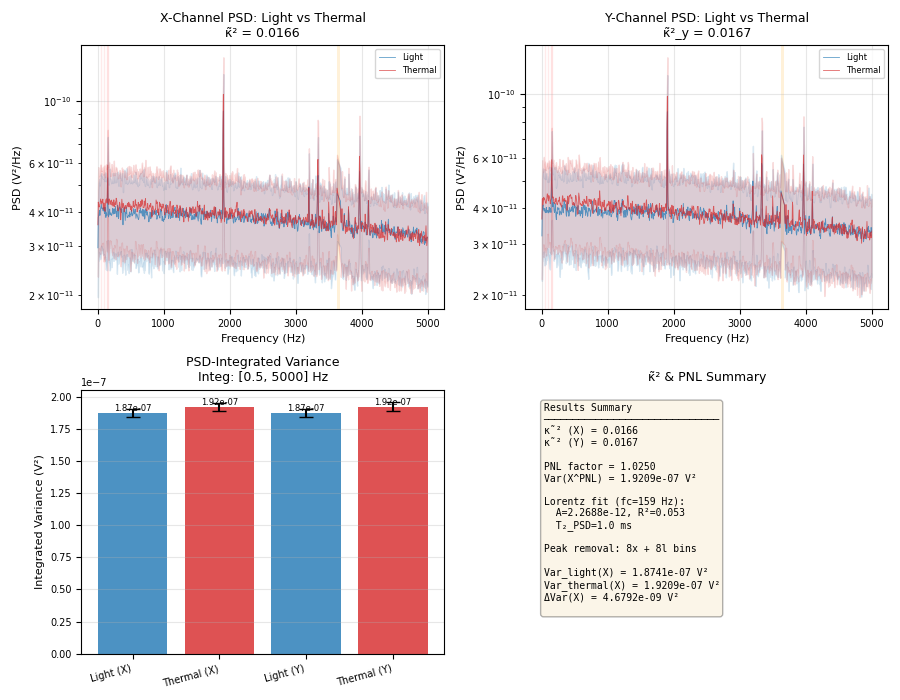

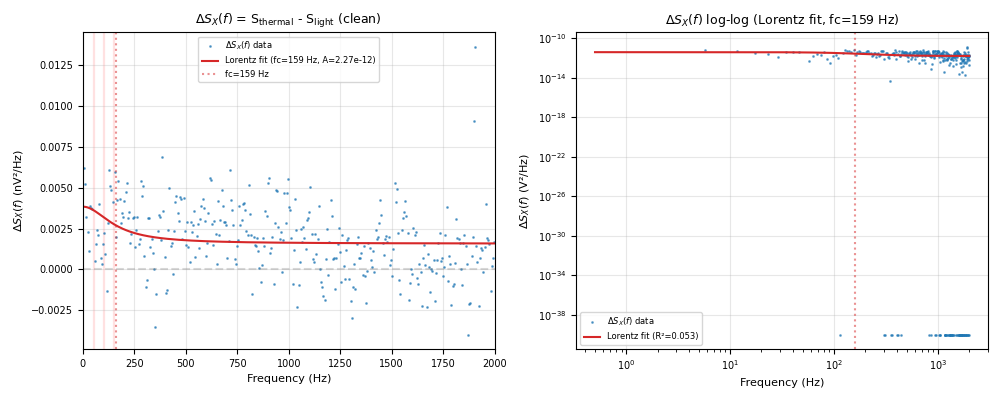

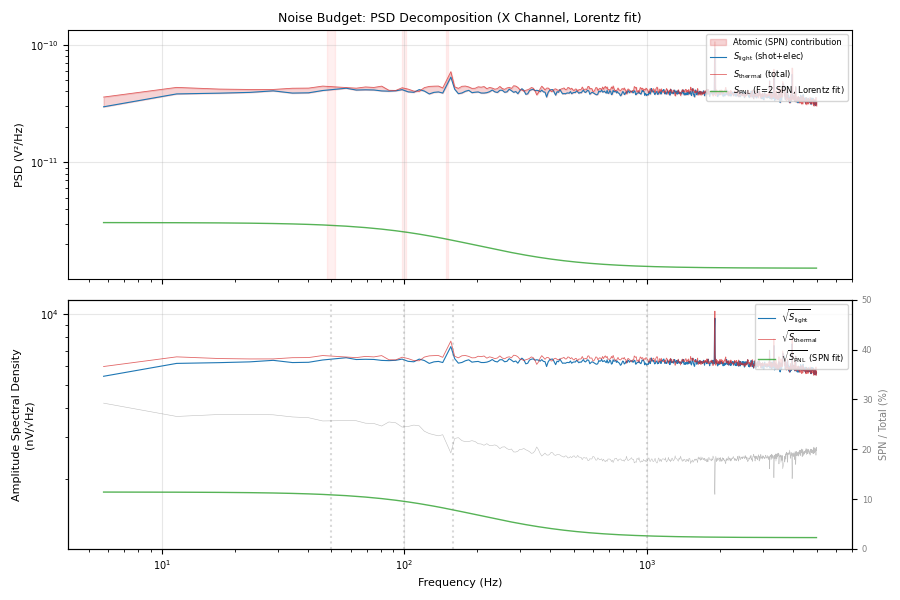

分析结果已保存: d:\Code\exp_agent\data\Projection_noise\0528_0911_thermal_pnl\results\analysis.yaml


In [40]:
# =====================================================================
# 对称性检查 & 结果可视化
# =====================================================================

plt.close('all')

clean_mask_x_light = notch_mask_light & peak_mask_x_light
clean_mask_x_thermal = notch_mask_thermal & peak_mask_x_thermal

# ---- 1. 均值检查 ----
mean_x_thermal = np.nanmean([np.mean(x2[r]) for r in range(n_repeats)])
mean_y_thermal = np.nanmean([np.mean(y2[r]) for r in range(n_repeats)])
threshold_mean = np.sqrt(var_x2_mean) / np.sqrt(x2.shape[1])

# ---- 2. X/Y 方差对称性 ----
symmetry_ratio = var_x2_mean / var_y2_mean if var_y2_mean > 0 else np.nan
symmetry_ok = 0.8 < symmetry_ratio < 1.2 if not np.isnan(symmetry_ratio) else False

# ---- 3. PSD 平坦性 ----
flat_band_light = (freqs_light >= PSD_INTEG_FMIN) & (freqs_light <= PSD_INTEG_FMAX) & clean_mask_x_light
psd_in_band = psd_x_light_mean[flat_band_light]
if len(psd_in_band) > 0:
    psd_fluctuation_db = 10 * np.log10(np.max(psd_in_band) / np.min(psd_in_band)) \
        if np.min(psd_in_band) > 0 else np.inf
    flatness_ok = psd_fluctuation_db < 6
else:
    psd_fluctuation_db = np.nan; flatness_ok = False

# ---- 4. 窄带尖峰检查 ----
n_peaks_total = n_peaks_x_thermal + n_peaks_x_light + n_peaks_y_thermal + n_peaks_y_light
peaks_ok = n_peaks_total == 0

print("=" * 55)
print("对称性与数据质量检查")
print("=" * 55)
print(f"1. 均值检查 (热态): mean(X)={mean_x_thermal:.6e}, mean(Y)={mean_y_thermal:.6e}")
print(f"   -> {'✓' if abs(mean_x_thermal)<10*threshold_mean else '⚠ 检查 DC 偏置'}")
print(f"2. X/Y 方差对称性: Var(X)/Var(Y)={symmetry_ratio:.3f}")
print(f"   -> {'✓' if symmetry_ok else '⚠ 检查解调相位'}")
print(f"3. PSD 平坦性: {psd_fluctuation_db:.1f} dB 起伏")
print(f"   -> {'✓ (<6 dB)' if flatness_ok else '⚠ 检查 LPF 设置'}")
print(f"4. 窄带尖峰: X_th={n_peaks_x_thermal}, X_li={n_peaks_x_light}, Y_th={n_peaks_y_thermal}, Y_li={n_peaks_y_light}")
print(f"   -> {'✓' if peaks_ok else '⚠ 已自动剔除'}")
print("=" * 55)

# ---- 辅助 ----
def find_mask_blocks(mask, freqs, fmin, fmax):
    band = (freqs >= fmin) & (freqs <= fmax)
    bad = ~mask & band
    if not np.any(bad): return []
    changes = np.diff(np.concatenate([[False], bad, [False]]).astype(int))
    starts = np.where(changes == 1)[0]; ends = np.where(changes == -1)[0] - 1
    return [(freqs[s], freqs[e]) for s, e in zip(starts, ends)]

# ---- 字体 ----
_rc_backup = {k: plt.rcParams[k] for k in ['font.size', 'axes.titlesize', 'axes.labelsize',
                                             'xtick.labelsize', 'ytick.labelsize', 'legend.fontsize']}
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9, 'axes.labelsize': 8,
                     'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7})

# =====================================================================
# Figure 1: PSD 对比 + 方差 + 汇总 (2×2)
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(9, 7))

# --- X 通道 PSD (clean mask) ---
ax1 = axes[0, 0]
for f0 in NOTCH_FREQS:
    ax1.axvspan(f0 - NOTCH_WIDTH, f0 + NOTCH_WIDTH, color='red', alpha=0.08)
plot_xl = (freqs_light >= PSD_INTEG_FMIN) & (freqs_light <= PSD_INTEG_FMAX) & clean_x
plot_xt = (freqs_thermal >= PSD_INTEG_FMIN) & (freqs_thermal <= PSD_INTEG_FMAX) & clean_x
for f_s, f_e in find_mask_blocks(peak_mask_x_light, freqs_light, PSD_INTEG_FMIN, PSD_INTEG_FMAX):
    ax1.axvspan(f_s, f_e, facecolor='orange', alpha=0.15)
ax1.plot(freqs_light[plot_xl], psd_x_light_mean[plot_xl], 'C0', alpha=0.7, lw=0.6, label='Light')
ax1.fill_between(freqs_light[plot_xl],
                 np.maximum(psd_x_light_mean[plot_xl] - psd_x_light_std[plot_xl], 1e-20),
                 psd_x_light_mean[plot_xl] + psd_x_light_std[plot_xl], color='C0', alpha=0.15)
ax1.plot(freqs_thermal[plot_xt], psd_x2_mean[plot_xt], 'C3', alpha=0.7, lw=0.6, label='Thermal')
ax1.fill_between(freqs_thermal[plot_xt],
                 np.maximum(psd_x2_mean[plot_xt] - psd_x2_std[plot_xt], 1e-20),
                 psd_x2_mean[plot_xt] + psd_x2_std[plot_xt], color='C3', alpha=0.15)
ax1.set_yscale('log'); ax1.set_xlabel('Frequency (Hz)'); ax1.set_ylabel('PSD (V²/Hz)')
ax1.set_title(f'X-Channel PSD: Light vs Thermal\nκ̃² = {kappa2_x:.4f}')
ax1.legend(fontsize=6); ax1.grid(True, alpha=0.3)

# --- Y 通道 PSD (clean mask) ---
ax2 = axes[0, 1]
for f0 in NOTCH_FREQS:
    ax2.axvspan(f0 - NOTCH_WIDTH, f0 + NOTCH_WIDTH, color='red', alpha=0.08)
plot_yl = (freqs_light >= PSD_INTEG_FMIN) & (freqs_light <= PSD_INTEG_FMAX) & clean_y
plot_yt = (freqs_thermal >= PSD_INTEG_FMIN) & (freqs_thermal <= PSD_INTEG_FMAX) & clean_y
for f_s, f_e in find_mask_blocks(peak_mask_y_light, freqs_light, PSD_INTEG_FMIN, PSD_INTEG_FMAX):
    ax2.axvspan(f_s, f_e, facecolor='orange', alpha=0.15)
ax2.plot(freqs_light[plot_yl], psd_y_light_mean[plot_yl], 'C0', alpha=0.7, lw=0.6, label='Light')
ax2.fill_between(freqs_light[plot_yl],
                 np.maximum(psd_y_light_mean[plot_yl] - psd_y_light_std[plot_yl], 1e-20),
                 psd_y_light_mean[plot_yl] + psd_y_light_std[plot_yl], color='C0', alpha=0.15)
ax2.plot(freqs_thermal[plot_yt], psd_y2_mean[plot_yt], 'C3', alpha=0.7, lw=0.6, label='Thermal')
ax2.fill_between(freqs_thermal[plot_yt],
                 np.maximum(psd_y2_mean[plot_yt] - psd_y2_std[plot_yt], 1e-20),
                 psd_y2_mean[plot_yt] + psd_y2_std[plot_yt], color='C3', alpha=0.15)
ax2.set_yscale('log'); ax2.set_xlabel('Frequency (Hz)'); ax2.set_ylabel('PSD (V²/Hz)')
ax2.set_title(f'Y-Channel PSD: Light vs Thermal\nκ̃²_y = {kappa2_y:.4f}')
ax2.legend(fontsize=6); ax2.grid(True, alpha=0.3)

# --- 方差对比 ---
ax3 = axes[1, 0]
phases = ['Light (X)', 'Thermal (X)', 'Light (Y)', 'Thermal (Y)']
var_values = [var_x_light_mean, var_x2_mean, var_y_light_mean, var_y2_mean]
var_errors = [var_x_light_std, var_x2_std, var_y_light_std, var_y2_std]
bars = ax3.bar(np.arange(4), var_values, yerr=var_errors, color=['C0','C3','C0','C3'], capsize=5, alpha=0.8)
ax3.set_xticks(np.arange(4)); ax3.set_xticklabels(phases, rotation=15, ha='right', fontsize=7)
ax3.set_ylabel('Integrated Variance (V²)')
ax3.set_title(f'PSD-Integrated Variance\nInteg: [{PSD_INTEG_FMIN}, {PSD_INTEG_FMAX}] Hz')
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, var_values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.2e}',
             ha='center', va='bottom', fontsize=6)

# --- 汇总 ---
ax4 = axes[1, 1]; ax4.axis('off')
summary_text = (
    f"Results Summary\n{'─'*30}\n"
    f"κ̃² (X) = {kappa2_x:.4f}\nκ̃² (Y) = {kappa2_y:.4f}\n\n"
    f"PNL factor = {pnl_factor:.4f}\nVar(X^PNL) = {var_pnl_x:.4e} V²\n\n"
    f"Lorentz fit (fc={fc_fit:.0f} Hz):\n"
    f"  A={A_fit:.4e}, R²={r2_fit:.3f}\n"
    f"  T₂_PSD={T2_psd*1000:.1f} ms\n\n"
    f"Peak removal: {n_peaks_x_thermal}x + {n_peaks_x_light}l bins\n\n"
    f"Var_light(X) = {var_x_light_mean:.4e} V²\nVar_thermal(X) = {var_x2_mean:.4e} V²\n"
    f"ΔVar(X) = {delta_var_x:.4e} V²\n"
)
ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes,
         fontsize=7, fontfamily='monospace', verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax4.set_title('κ̃² & PNL Summary')

plt.tight_layout()
fig.savefig(results_dir / "projection_noise_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

# =====================================================================
# Figure 2: ΔS(f) 洛伦兹拟合 (0.5-2000 Hz)
# =====================================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4))

fit_band = (freqs_thermal >= PSD_INTEG_FMIN) & (freqs_thermal <= FIT_FMAX) & clean_x

ax_l = axes2[0]
ax_l.plot(freqs_thermal[fit_band], ds_x[fit_band] * 1e9, 'C0.', markersize=2, alpha=0.6,
          label=r'$\Delta S_X(f)$ data')
ax_l.axhline(0, color='gray', ls='--', alpha=0.3)
for f0 in NOTCH_FREQS:
    if f0 <= FIT_FMAX:
        ax_l.axvspan(f0 - NOTCH_WIDTH, f0 + NOTCH_WIDTH, color='red', alpha=0.08)
ax_l.plot(f_fit_smooth, ds_fit_smooth * 1e9, 'C3-', linewidth=1.5,
          label=f'Lorentz fit (fc={fc_fit:.0f} Hz, A={A_fit:.2e})')
ax_l.axvline(fc_fit, color='C3', ls=':', alpha=0.5, label=f'fc={fc_fit:.0f} Hz')
ax_l.set_xlabel('Frequency (Hz)'); ax_l.set_ylabel(r'$\Delta S_X(f)$ (nV²/Hz)')
ax_l.set_title(r'$\Delta S_X(f)$ = S$_{\rm thermal}$ - S$_{\rm light}$ (clean)')
ax_l.legend(fontsize=6); ax_l.grid(True, alpha=0.3); ax_l.set_xlim(0, FIT_FMAX)

ax_r = axes2[1]
ax_r.loglog(freqs_thermal[fit_band], np.maximum(ds_x[fit_band], 1e-40), 'C0.', markersize=2,
            alpha=0.6, label=r'$\Delta S_X(f)$ data')
ax_r.loglog(f_fit_smooth, np.maximum(ds_fit_smooth, 1e-40), 'C3-', linewidth=1.5,
            label=f'Lorentz fit (R²={r2_fit:.3f})')
ax_r.axvline(fc_fit, color='C3', ls=':', alpha=0.5)
ax_r.set_xlabel('Frequency (Hz)'); ax_r.set_ylabel(r'$\Delta S_X(f)$ (V²/Hz)')
ax_r.set_title(fr'$\Delta S_X(f)$ log-log (Lorentz fit, fc={fc_fit:.0f} Hz)')
ax_r.legend(fontsize=6); ax_r.grid(True, alpha=0.3)

plt.tight_layout()
fig2.savefig(results_dir / "ds_lorentz_fit.png", dpi=150, bbox_inches="tight")
plt.show()

# =====================================================================
# Figure 3: 噪声预算 — 用洛伦兹拟合值画 SPN 曲线
# =====================================================================
fig3, axes3 = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

nb_mask = (freqs_thermal >= PSD_INTEG_FMIN) & (freqs_thermal <= PSD_INTEG_FMAX) & clean_x
f_nb = freqs_thermal[nb_mask]
s_light_nb = psd_x_light_mean[nb_mask]
s_thermal_nb = psd_x2_mean[nb_mask]
s_pnl_nb = s_pnl_fit[nb_mask]

ax_top = axes3[0]
ax_top.fill_between(f_nb, s_light_nb, s_thermal_nb, color='C3', alpha=0.2,
                     label='Atomic (SPN) contribution')
ax_top.loglog(f_nb, s_light_nb, 'C0', lw=0.8, label=r'$S_{\rm light}$ (shot+elec)')
ax_top.loglog(f_nb, s_thermal_nb, 'C3', lw=0.6, alpha=0.7, label=r'$S_{\rm thermal}$ (total)')
ax_top.loglog(f_nb, s_pnl_nb, 'C2', lw=1.0, alpha=0.8,
              label=r'$S_{\rm PNL}$ (F=2 SPN, Lorentz fit)')
for f0 in NOTCH_FREQS:
    ax_top.axvspan(f0 - NOTCH_WIDTH, f0 + NOTCH_WIDTH, color='red', alpha=0.06)
ax_top.set_ylabel('PSD (V²/Hz)')
ax_top.set_title('Noise Budget: PSD Decomposition (X Channel, Lorentz fit)')
ax_top.legend(fontsize=6, loc='upper right'); ax_top.grid(True, alpha=0.3)

ax_bot = axes3[1]
amp_light = np.sqrt(s_light_nb)
amp_total = np.sqrt(s_thermal_nb)
amp_pnl = np.sqrt(s_pnl_nb)
spn_fraction = amp_pnl / amp_total * 100

ax_bot.loglog(f_nb, amp_light * 1e9, 'C0', lw=0.8, label=r'$\sqrt{S_{\rm light}}$')
ax_bot.loglog(f_nb, amp_total * 1e9, 'C3', lw=0.6, alpha=0.7, label=r'$\sqrt{S_{\rm thermal}}$')
ax_bot.loglog(f_nb, amp_pnl * 1e9, 'C2', lw=1.0, alpha=0.8,
              label=r'$\sqrt{S_{\rm PNL}}$ (SPN fit)')
ax_bot.set_ylabel('Amplitude Spectral Density\n(nV/√Hz)')
ax_bot.set_xlabel('Frequency (Hz)')
ax_bot.legend(fontsize=6, loc='upper right'); ax_bot.grid(True, alpha=0.3)

ax_frac = ax_bot.twinx()
ax_frac.semilogx(f_nb, spn_fraction, 'gray', lw=0.4, alpha=0.5)
ax_frac.set_ylabel('SPN / Total (%)', color='gray', fontsize=7)
ax_frac.tick_params(axis='y', labelcolor='gray', labelsize=6)
ax_frac.set_ylim(0, max(50, np.percentile(spn_fraction, 99) * 1.2))

for f_mark in [50, 100, fc_fit, 1000]:
    ax_bot.axvline(f_mark, color='gray', ls=':', alpha=0.3)

plt.tight_layout()
fig3.savefig(results_dir / "noise_budget.png", dpi=150, bbox_inches="tight")
plt.show()

plt.rcParams.update(_rc_backup)

# ========== 保存分析结果 ==========
analysis_path = results_dir / "analysis.yaml"
analysis = {
    "variances": {
        "light_noise": {"var_x_mean": float(var_x_light_mean), "var_x_std": float(var_x_light_std),
                        "var_y_mean": float(var_y_light_mean), "var_y_std": float(var_y_light_std)},
        "thermal": {"var_x_mean": float(var_x2_mean), "var_x_std": float(var_x2_std),
                    "var_y_mean": float(var_y2_mean), "var_y_std": float(var_y2_std)},
    },
    "kappa2": {
        "kappa2_x": float(kappa2_x), "kappa2_y": float(kappa2_y),
        "raw_ratio_x": float(kappa2_raw_x), "raw_ratio_y": float(kappa2_raw_y),
        "delta_var_x": float(delta_var_x), "delta_var_y": float(delta_var_y),
        "correction_factors": {"pnl_thermal_ratio": PNL_THERMAL_RATIO, "f1_correction": F1_CORRECTION},
    },
    "pnl": {"pnl_factor": float(pnl_factor), "var_x_pnl": float(var_pnl_x)},
    "spn_spectrum": {"s_light_baseline_x": float(s_light_baseline_x),
                     "s_light_baseline_y": float(s_light_baseline_y)},
    "lorentz_fit": {
        "fit_ok": bool(lorentz_fit_ok), "method": "linear_regression_fixed_fc",
        "fc_fixed_Hz": FC_FIXED,
        "A": float(A_fit), "fc_Hz": float(fc_fit),
        "T2_psd_ms": float(T2_psd * 1000) if not np.isnan(T2_psd) else None,
        "r2": float(r2_fit), "fit_fmax_Hz": FIT_FMAX,
    },
    "peak_removal": {
        "threshold": PEAK_THRESHOLD, "dilate": PEAK_DILATE,
        "n_bins_removed": {"x_thermal": int(n_peaks_x_thermal), "x_light": int(n_peaks_x_light),
                           "y_thermal": int(n_peaks_y_thermal), "y_light": int(n_peaks_y_light)},
    },
    "symmetry_checks": {
        "mean_x_thermal": float(mean_x_thermal), "mean_y_thermal": float(mean_y_thermal),
        "var_ratio_xy": float(symmetry_ratio), "symmetry_ok": bool(symmetry_ok),
        "psd_flatness_db": float(psd_fluctuation_db), "flatness_ok": bool(flatness_ok),
        "n_narrow_peaks": int(n_peaks_total), "peaks_ok": bool(peaks_ok),
    },
    "psd_params": {
        "nperseg": NPERSEG, "integ_fmin": PSD_INTEG_FMIN, "integ_fmax": PSD_INTEG_FMAX,
        "notch_freqs": NOTCH_FREQS, "notch_width": NOTCH_WIDTH,
        "peak_threshold": PEAK_THRESHOLD, "peak_dilate": PEAK_DILATE,
        "sampling_rate_thermal": float(actual_rate),
    },
}
with open(analysis_path, "w", encoding="utf-8") as f:
    yaml.dump(analysis, f, default_flow_style=False, allow_unicode=True)
print(f"分析结果已保存: {analysis_path}")

In [ ]:
# ========== 安全断开 ==========

print("正在断开设备...")

# 将主磁场恢复到偏置值（安全状态）
try:
    gs.set_current(MAIN_FIELD_OFFSET_mA / 1000.0)
    print(f"  主磁场已恢复到偏置值: {MAIN_FIELD_OFFSET_mA} mA")
except Exception as e:
    print(f"  恢复磁场失败: {e}")

for name, dev in devices.items():
    if hasattr(dev, "disconnect"):
        try:
            dev.disconnect()
            print(f"  {name} 已断开")
        except Exception as e:
            print(f"  {name} 断开失败: {e}")

print("所有设备已断开")

正在断开设备...
  主磁场已恢复到偏置值: 5.0 mA
  gs200 已断开
  dg_laser 已断开
  dg_temp 已断开
  tec 已断开
  hf2 已断开
所有设备已断开
